In [1]:
import pandas as pd
df_ml = pd.read_csv("data_processed/df_ml_clean.csv")

print(df_ml.shape)
df_ml.head()

(96, 6)


,Lat,Long,Depth_km,Temp_obs,Cond,Hflow
0,-30.942,-57.518,3,84,3.449467,78
1,-30.942,-57.518,4,111,3.537100,78
2,-30.942,-57.518,5,137,3.589680,78
3,-30.942,-57.518,6,163,3.624733,78
4,-30.949,-57.518,3,100,3.252200,102


In [2]:
from sklearn.model_selection import train_test_split

feature_cols = ['Lat', 'Long', 'Depth_km', 'Temp_obs', 'Cond']
target_col = 'Hflow'

X = df_ml[feature_cols].values
y = df_ml[target_col].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(76, 5) (20, 5)


In [3]:
# Method ML Random and Gradient

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

rf = RandomForestRegressor(random_state=42)
gbr = GradientBoostingRegressor(random_state=42)

rf.fit(X_train, y_train)
gbr.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_gbr = gbr.predict(X_test)

In [4]:
# Method ML Stacking

from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

stack = StackingRegressor(
    estimators=[
        ('rf', RandomForestRegressor(random_state=42)),
        ('gbr', GradientBoostingRegressor(random_state=42))
    ],
    final_estimator=LinearRegression()
)

stack.fit(X_train, y_train)

y_pred_stack = stack.predict(X_test)

In [5]:
def metrics(y_true, y_pred):
    import numpy as np
    err = y_pred - y_true
    rmse = np.sqrt(np.mean(err**2))
    mae = np.mean(np.abs(err))
    mape = np.mean(np.abs(err)/(np.abs(y_true)+1e-8))*100
    return rmse, mae, mape

print("RF:", metrics(y_test, y_pred_rf))
print("GBR:", metrics(y_test, y_pred_gbr))
print("STACK:", metrics(y_test, y_pred_stack))

RF: (np.float64(5.042114139921865), np.float64(3.3375), np.float64(4.543066040383513))
GBR: (np.float64(6.453639107398339), np.float64(4.176899512471877), np.float64(5.427872083222692))
STACK: (np.float64(5.283352060303424), np.float64(3.4544409029549703), np.float64(4.664087701192584))


In [6]:
# Classic interpolation

import numpy as np
import pandas as pd
from scipy.interpolate import griddata

# Metrics

def regression_metrics(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    err = y_pred - y_true

    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err**2))
    mape = np.mean(np.abs(err) / (np.abs(y_true) + eps)) * 100

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE_%": mape
    }

target_col = 'Hflow'
interp_method = 'linear'  # puedes probar: 'linear', 'nearest', 'cubic'

# Data

df_interp = df_ml[['Lat', 'Long', 'Depth_km', target_col]].dropna().copy()

print("Número total de puntos:", len(df_interp))

# Coordinates
points_all = df_interp[['Long', 'Lat', 'Depth_km']].values
values_all = df_interp[target_col].values

# Leave-one-out (LOO)

y_true_all = []
y_pred_all = []

for i in range(len(points_all)):
    
    # separate train/test
    mask = np.ones(len(points_all), dtype=bool)
    mask[i] = False

    train_points = points_all[mask]
    train_values = values_all[mask]

    test_point = points_all[i]
    y_true = values_all[i]

    # main prediction
    y_pred = griddata(
        train_points,
        train_values,
        test_point.reshape(1, 3),
        method=interp_method
    )[0]

    
    if not np.isfinite(y_pred):
        y_pred = griddata(
            train_points,
            train_values,
            test_point.reshape(1, 3),
            method='nearest'
        )[0]

    y_true_all.append(y_true)
    y_pred_all.append(y_pred)


# Results

metrics_interp = regression_metrics(y_true_all, y_pred_all)

print("\nInterpolación clásica 3D:")
for k, v in metrics_interp.items():
    print(f"{k}: {v:.4f}")

Número total de puntos: 96

Interpolación clásica 3D:
RMSE: 15.6527
MAE: 11.2464
MAPE_%: 17.6728


In [7]:
metrics_rf = {"RMSE": 5.04, "MAE":  3.34, "MAPE_%": 4.54}
metrics_gbr = {"RMSE": 6.45, "MAE": 4.18, "MAPE_%": 5.43}
metrics_stack = {"RMSE": 5.28, "MAE": 3.45, "MAPE_%": 4.66}
metrics_interp = {"RMSE": 15.65, "MAE": 11.24, "MAPE_%": 17.67}

In [8]:
import pandas as pd

results = pd.DataFrame([
    {"Model": "Random Forest", **metrics_rf},
    {"Model": "Gradient Boosting", **metrics_gbr},
    {"Model": "Stacking", **metrics_stack},
    {"Model": "Interpolation", **metrics_interp}
])


results = results.rename(columns={"MAPE_%": "MAPE"})

print(results)

               Model   RMSE    MAE   MAPE
0      Random Forest   5.04   3.34   4.54
1  Gradient Boosting   6.45   4.18   5.43
2           Stacking   5.28   3.45   4.66
3      Interpolation  15.65  11.24  17.67


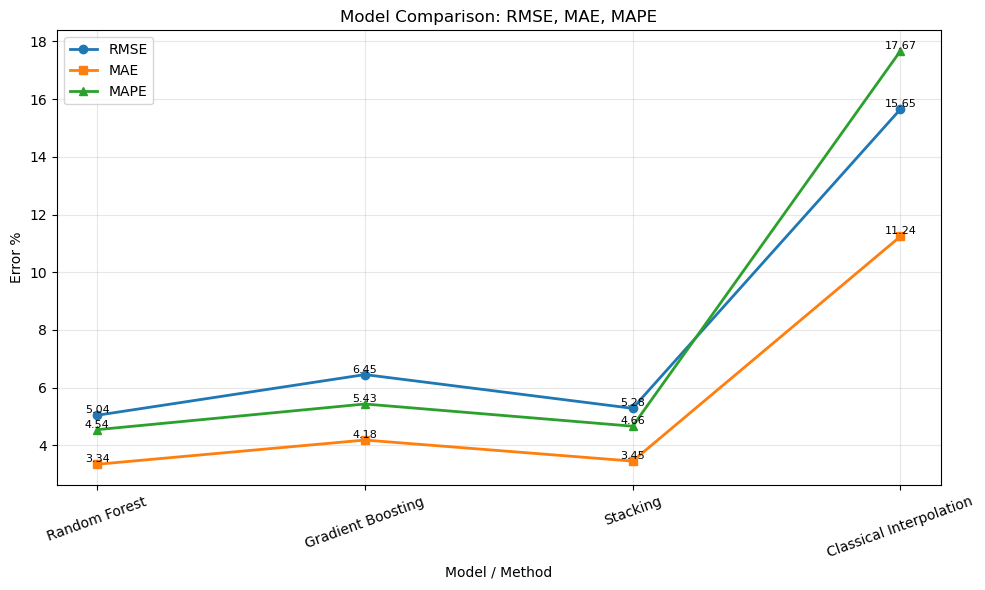

In [9]:
import matplotlib.pyplot as plt
import numpy as np

rmse_interp = metrics_interp['RMSE']
mae_interp = metrics_interp['MAE']
mape_interp = metrics_interp['MAPE_%']
rmse_rf = metrics_rf['RMSE']
rmse_gbr = metrics_gbr['RMSE']
rmse_stack = metrics_stack['RMSE']
mae_rf = metrics_rf['MAE']
mae_gbr = metrics_gbr['MAE']
mae_stack = metrics_stack['MAE']
mape_rf = metrics_rf['MAPE_%']
mape_gbr = metrics_gbr['MAPE_%']
mape_stack = metrics_stack['MAPE_%']




models = ['Random Forest', 'Gradient Boosting', 'Stacking', 'Classical Interpolation']

rmse_vals = [rmse_rf, rmse_gbr, rmse_stack, rmse_interp]
mae_vals = [mae_rf, mae_gbr, mae_stack, mae_interp]
mape_vals = [mape_rf, mape_gbr, mape_stack, mape_interp]

x = np.arange(len(models))

plt.figure(figsize=(10, 6))

# Lines
plt.plot(x, rmse_vals, marker='o', linewidth=2, label='RMSE')
plt.plot(x, mae_vals, marker='s', linewidth=2, label='MAE')
plt.plot(x, mape_vals, marker='^', linewidth=2, label='MAPE')

# Labels
plt.xticks(x, models, rotation=20)
plt.xlabel('Model / Method')
plt.ylabel('Error %')
plt.title('Model Comparison: RMSE, MAE, MAPE')

plt.legend()

# Values on the points
for i in range(len(models)):
    plt.text(x[i], rmse_vals[i], f'{rmse_vals[i]:.2f}', ha='center', va='bottom', fontsize=8)
    plt.text(x[i], mae_vals[i], f'{mae_vals[i]:.2f}', ha='center', va='bottom', fontsize=8)
    plt.text(x[i], mape_vals[i], f'{mape_vals[i]:.2f}', ha='center', va='bottom', fontsize=8)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("line_comparison_metrics.png", dpi=600, bbox_inches='tight')
plt.show()

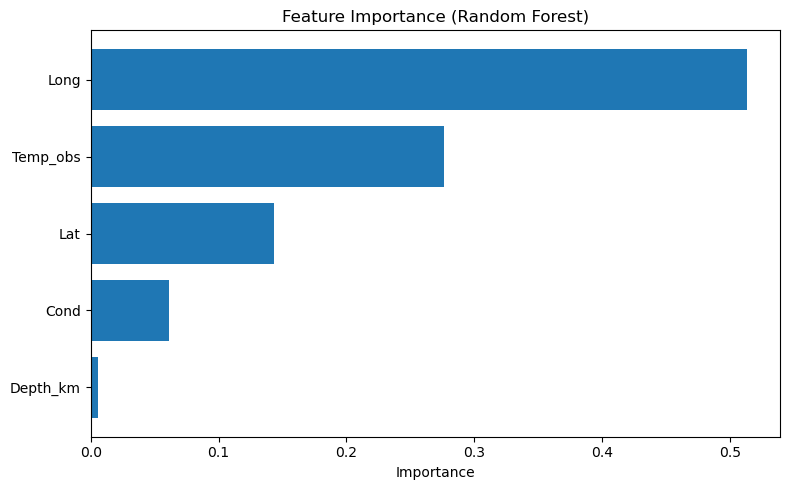

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Importances
importances = rf.feature_importances_
features = feature_cols

# Create DataFrame
df_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Graphic
plt.figure(figsize=(8, 5))
plt.barh(df_imp['Feature'], df_imp['Importance'])
plt.gca().invert_yaxis() 
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error


# Clean copy

df_hybrid = df_ml.copy()


# Physics features based on Fourier

# Vertical gradient
df_hybrid['grad_T'] = df_hybrid['Temp_obs'] / df_hybrid['Depth_km']

# Physics flow
df_hybrid['H_physics'] = df_hybrid['Cond'] * df_hybrid['grad_T']


# Features and target

feature_cols_hybrid = ['Lat', 'Long', 'Depth_km', 'Temp_obs', 'Cond', 'grad_T', 'H_physics']
target_col = 'Hflow'

X = df_hybrid[feature_cols_hybrid].values
y = df_hybrid[target_col].values


# Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Metrics

def metrics(y_true, y_pred):
    err = y_pred - y_true
    rmse = np.sqrt(np.mean(err**2))
    mae = np.mean(np.abs(err))
    mape = np.mean(np.abs(err) / (np.abs(y_true) + 1e-8)) * 100
    return rmse, mae, mape


# Models

rf_hybrid = RandomForestRegressor(random_state=42)
gbr_hybrid = GradientBoostingRegressor(random_state=42)

stack_hybrid = StackingRegressor(
    estimators=[
        ('rf', RandomForestRegressor(random_state=42)),
        ('gbr', GradientBoostingRegressor(random_state=42))
    ],
    final_estimator=LinearRegression()
)


# Training models

rf_hybrid.fit(X_train, y_train)
gbr_hybrid.fit(X_train, y_train)
stack_hybrid.fit(X_train, y_train)


# Prediction

y_pred_rf_hybrid = rf_hybrid.predict(X_test)
y_pred_gbr_hybrid = gbr_hybrid.predict(X_test)
y_pred_stack_hybrid = stack_hybrid.predict(X_test)


# Results

rmse_rf_h, mae_rf_h, mape_rf_h = metrics(y_test, y_pred_rf_hybrid)
rmse_gbr_h, mae_gbr_h, mape_gbr_h = metrics(y_test, y_pred_gbr_hybrid)
rmse_stack_h, mae_stack_h, mape_stack_h = metrics(y_test, y_pred_stack_hybrid)

print("HYBRID RANDOM FOREST :", rmse_rf_h, mae_rf_h, mape_rf_h)
print("HYBRID GBR :", rmse_gbr_h, mae_gbr_h, mape_gbr_h)
print("HYBRID STACKING :", rmse_stack_h, mae_stack_h, mape_stack_h)

HYBRID RANDOM FOREST : 3.0429089700482335 1.6244999999999998 2.471695368798831
HYBRID GBR : 2.5041926487851356 1.2796337682193453 1.879061978491503
HYBRID STACKING : 2.7073588938478688 1.4337645367327352 2.061114419022422


     Feature  Importance
6  H_physics    0.544106
5     grad_T    0.393460
1       Long    0.038635
0        Lat    0.018855
4       Cond    0.004185
3   Temp_obs    0.000735
2   Depth_km    0.000024


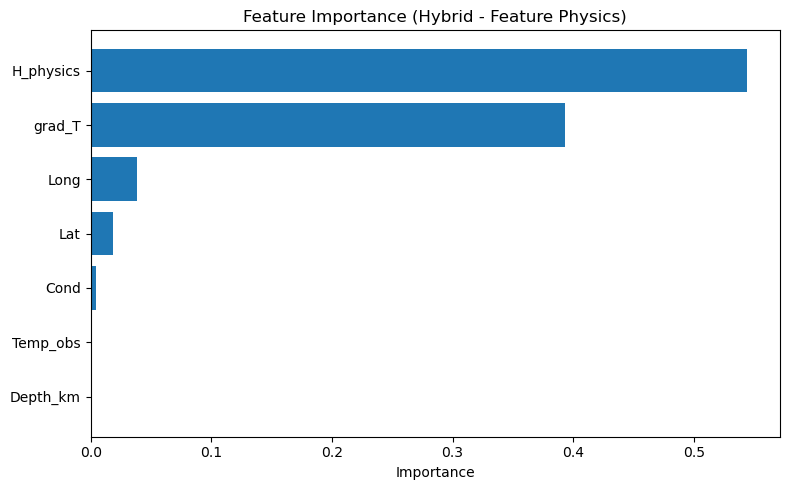

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor


# Physics features
# =========================
df_ml['grad_T'] = df_ml['Temp_obs'] / df_ml['Depth_km']
df_ml['H_physics'] = df_ml['Cond'] * df_ml['grad_T']


# Model features

feature_cols_hybrid = [
    'Lat',
    'Long',
    'Depth_km',
    'Temp_obs',
    'Cond',
    'grad_T',
    'H_physics'
]

X = df_ml[feature_cols_hybrid]
y = df_ml['Hflow']


# Training model

rf_hybrid = RandomForestRegressor(random_state=42)
rf_hybrid.fit(X, y)


# Feature importance

importances = rf_hybrid.feature_importances_

df_imp = pd.DataFrame({
    'Feature': feature_cols_hybrid,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(df_imp)


# Graphics

plt.figure(figsize=(8, 5))
plt.barh(df_imp['Feature'], df_imp['Importance'])
plt.gca().invert_yaxis()
plt.title('Feature Importance (Hybrid - Feature Physics)')
plt.xlabel('Importance')

plt.tight_layout()
plt.show()

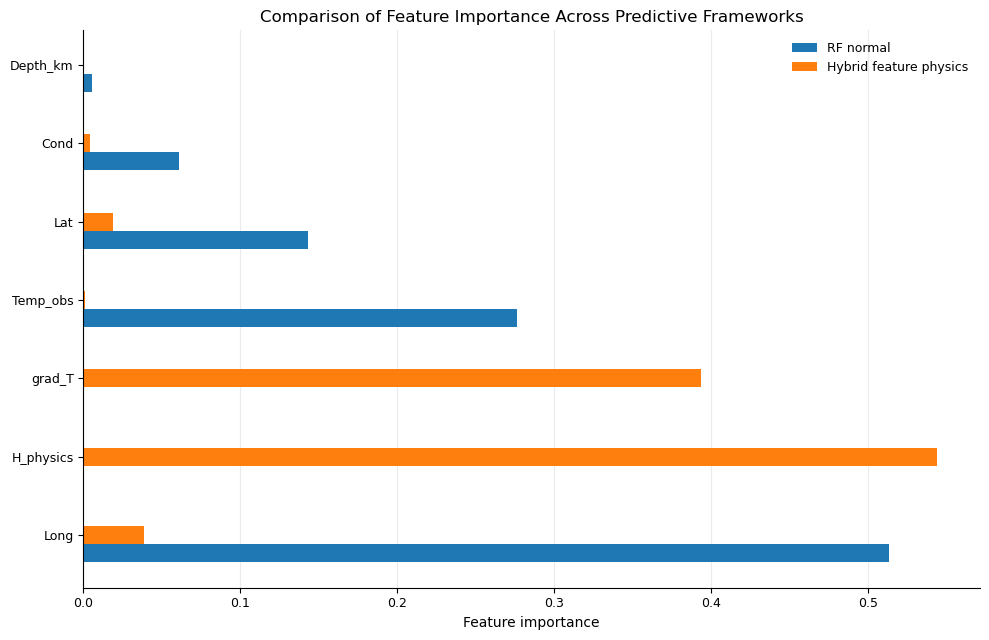

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Models importances

df_imp_rf = pd.DataFrame({
    'Feature': feature_cols,
    'RF normal': rf.feature_importances_
})

df_imp_hybrid = pd.DataFrame({
    'Feature': feature_cols_hybrid,
    'Hybrid feature physics': rf_hybrid.feature_importances_
})



df_compare = df_imp_rf.merge(df_imp_hybrid, on='Feature', how='outer')
df_compare = df_compare.fillna(0)

# Order by importances
df_compare['Total'] = (
    df_compare['RF normal'] +
    df_compare['Hybrid feature physics']
)
df_compare = df_compare.sort_values('Total', ascending=False).drop(columns='Total')


plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9
})

fig, ax = plt.subplots(figsize=(10, 6.5))

y = np.arange(len(df_compare))
h = 0.23

ax.barh(y - h, df_compare['RF normal'], height=h, label='RF normal')
ax.barh(y, df_compare['Hybrid feature physics'], height=h, label='Hybrid feature physics')

ax.set_yticks(y)
ax.set_yticklabels(df_compare['Feature'])
ax.set_xlabel('Feature importance')
ax.set_title('Comparison of Feature Importance Across Predictive Frameworks')

ax.grid(axis='x', alpha=0.25, linewidth=0.8)
ax.set_axisbelow(True)

# Remove unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(frameon=False, loc='upper right')

plt.tight_layout()
plt.savefig("feature_importance_comparison_Q1.png", dpi=600, bbox_inches='tight')
plt.show()

SHAP INPUT CHECK
X shape: (96, 7)
y shape: (96,)
Features: ['Lat', 'Long', 'Depth_km', 'Temp_obs', 'Cond', 'grad_T', 'H_physics']
SHAP values shape: (96, 7)

MEAN ABSOLUTE SHAP IMPORTANCE
     Feature  MeanAbsSHAP
0  H_physics     8.696637
1     grad_T     6.259689
2       Long     2.620735
3        Lat     1.236828
4       Cond     0.173163
5   Temp_obs     0.055867
6   Depth_km     0.007358


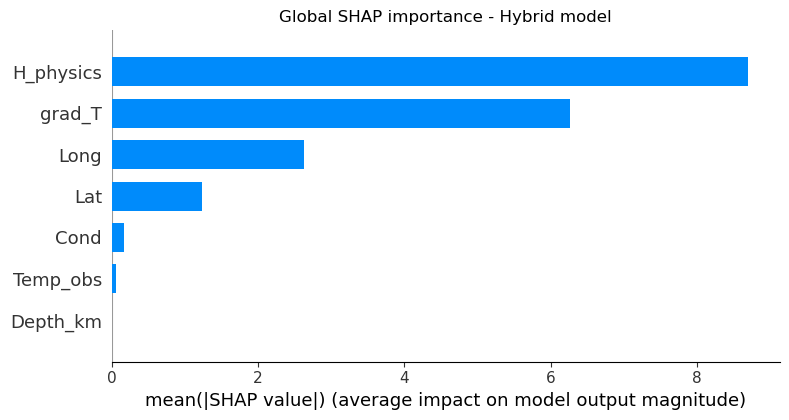

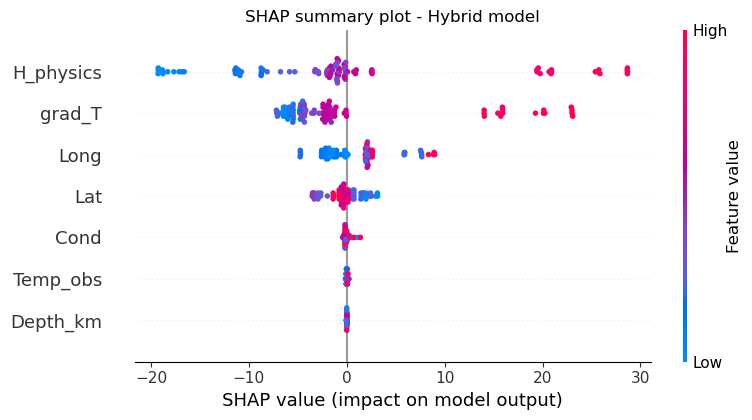

<Figure size 680x500 with 0 Axes>

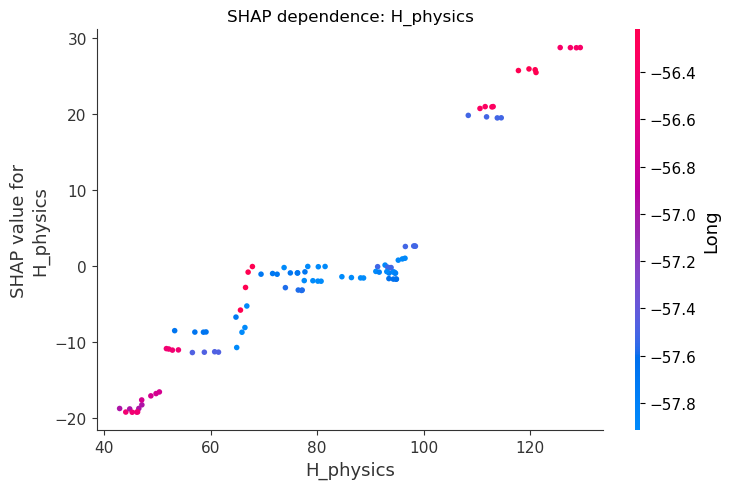

<Figure size 680x500 with 0 Axes>

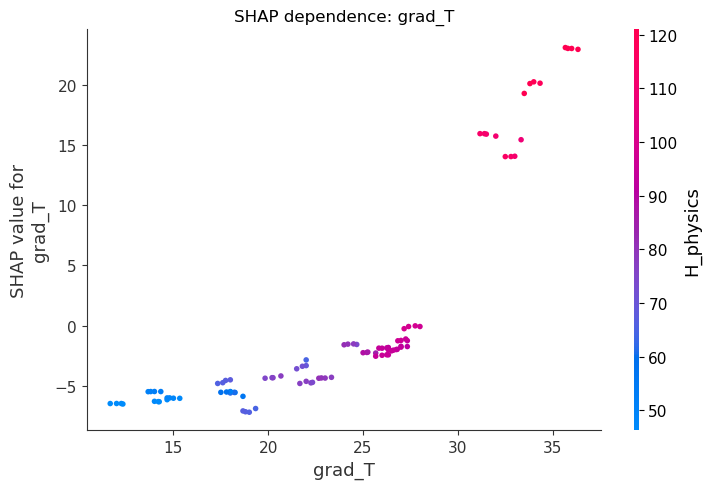

<Figure size 680x500 with 0 Axes>

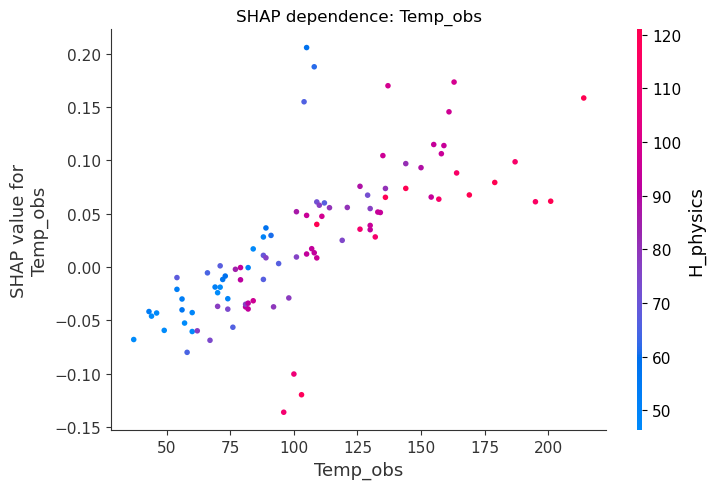

<Figure size 680x500 with 0 Axes>

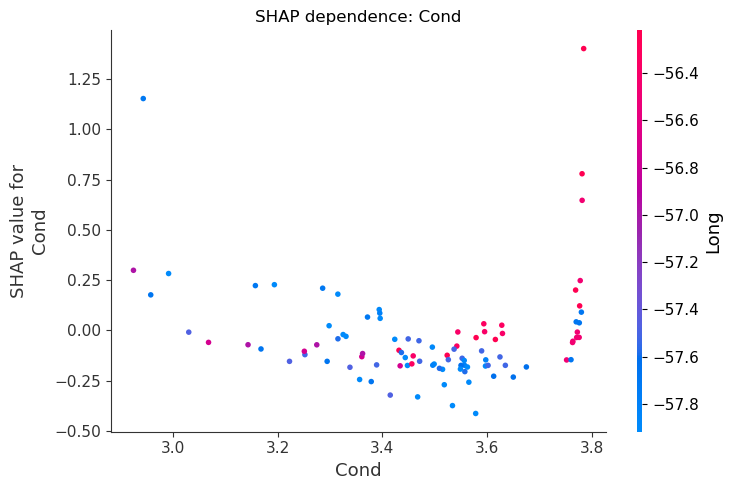

<Figure size 680x500 with 0 Axes>

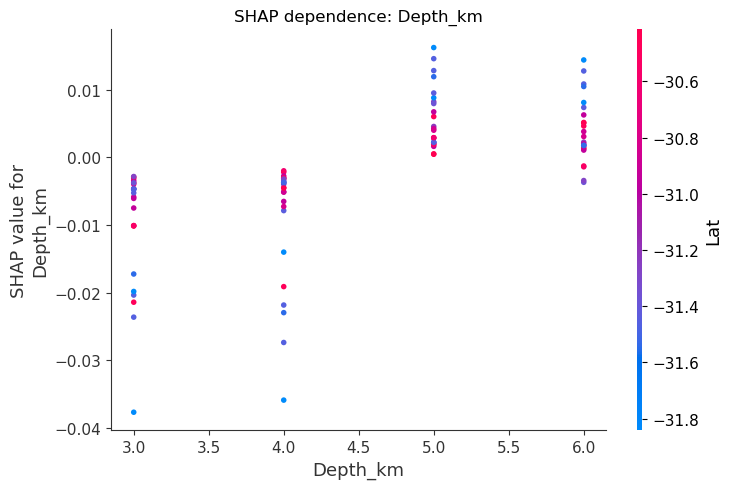

<Figure size 680x500 with 0 Axes>

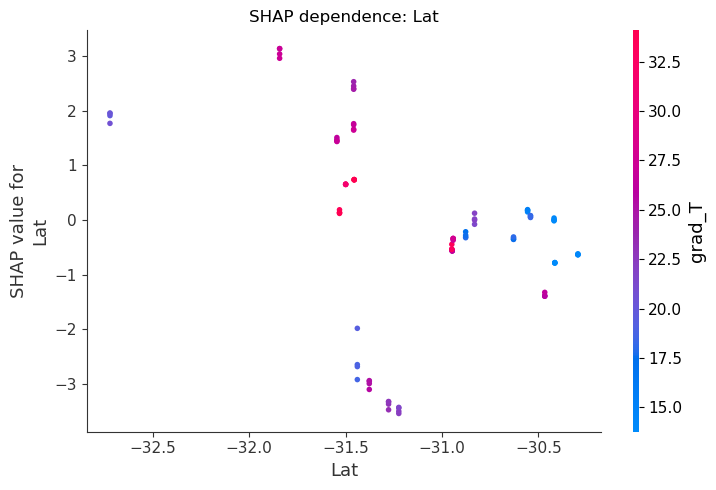

<Figure size 680x500 with 0 Axes>

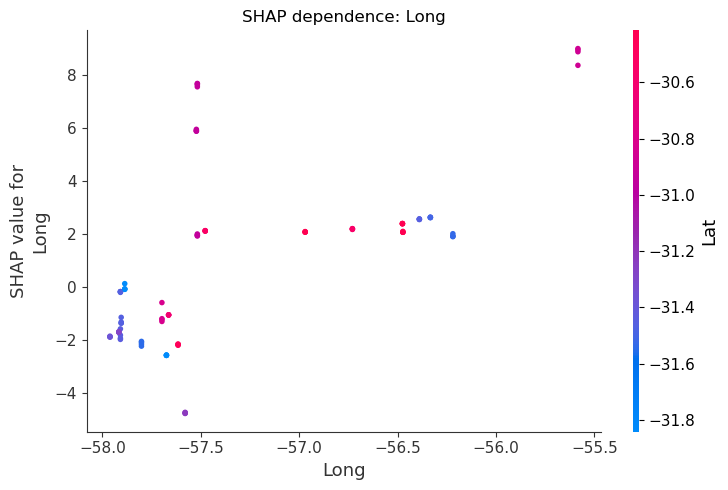

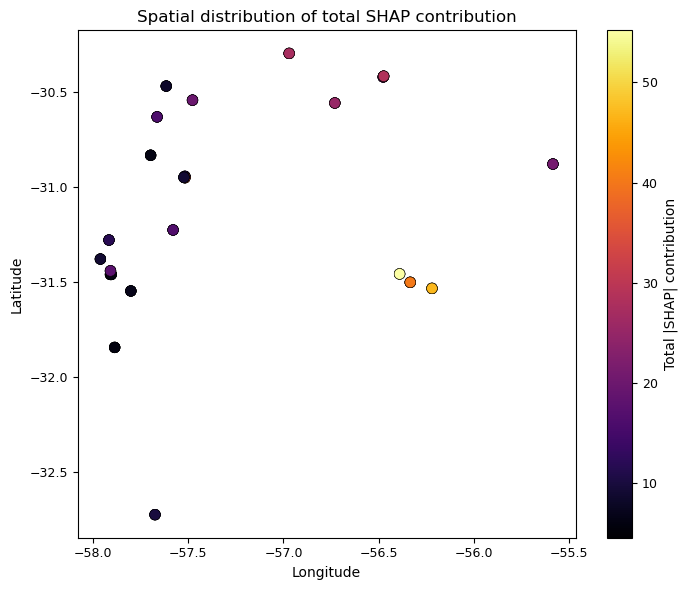

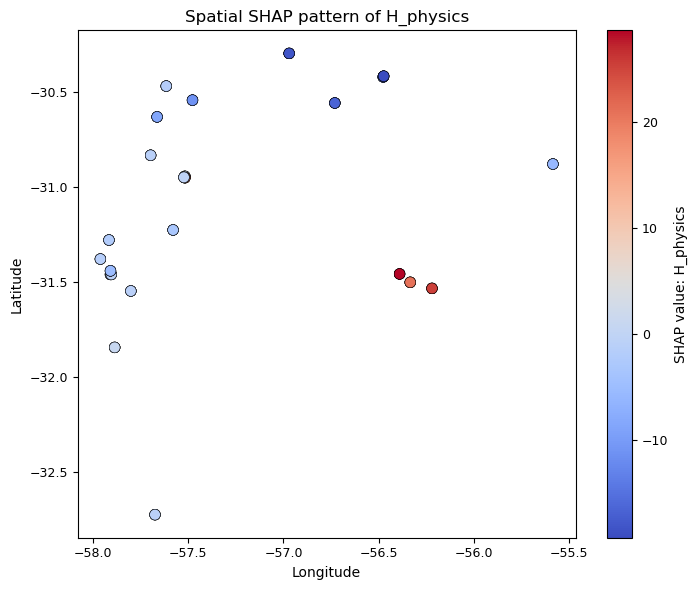

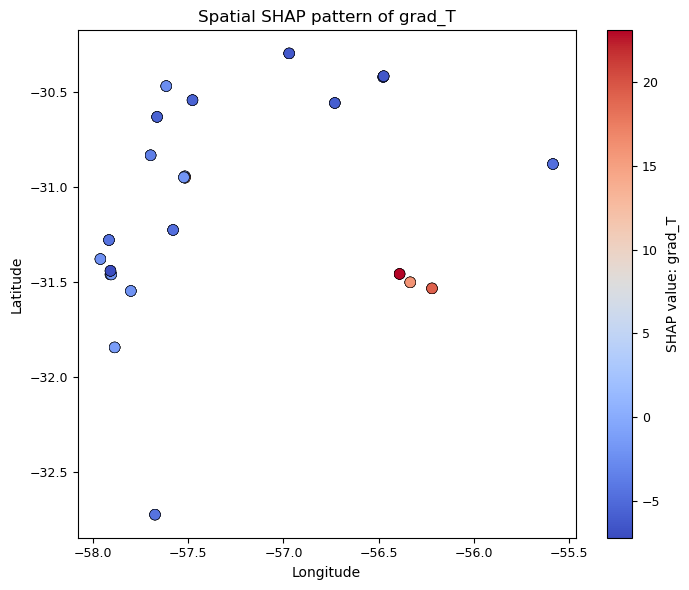

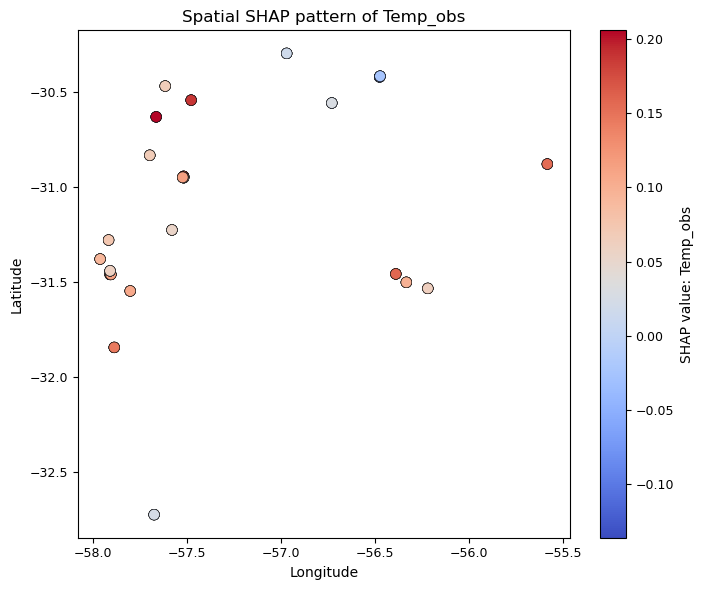

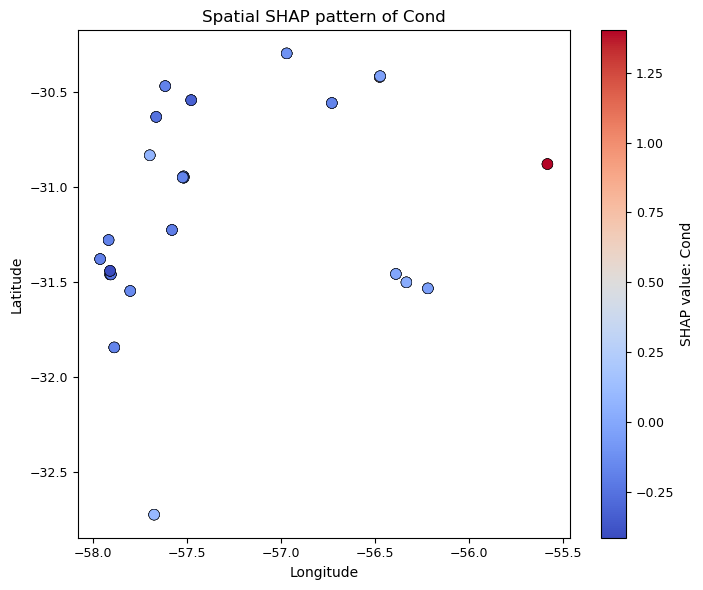

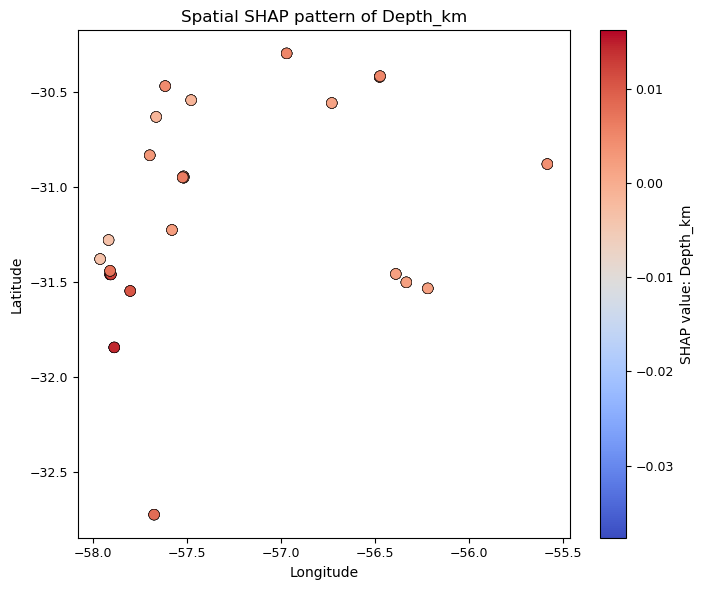

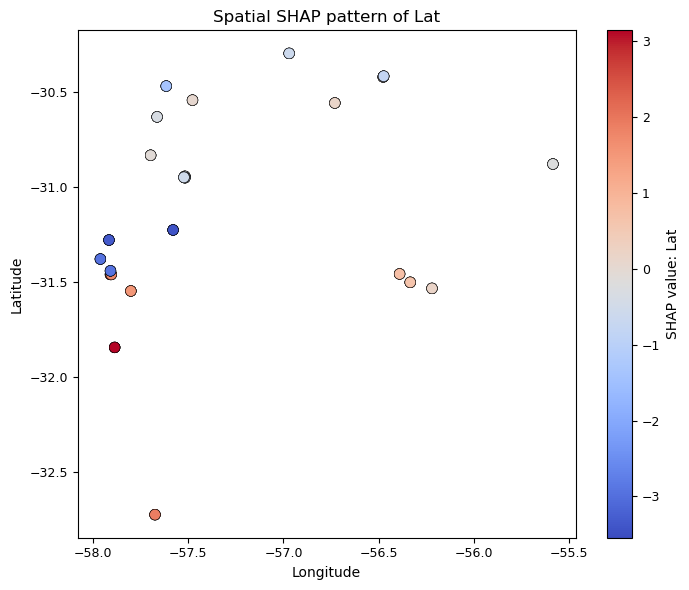

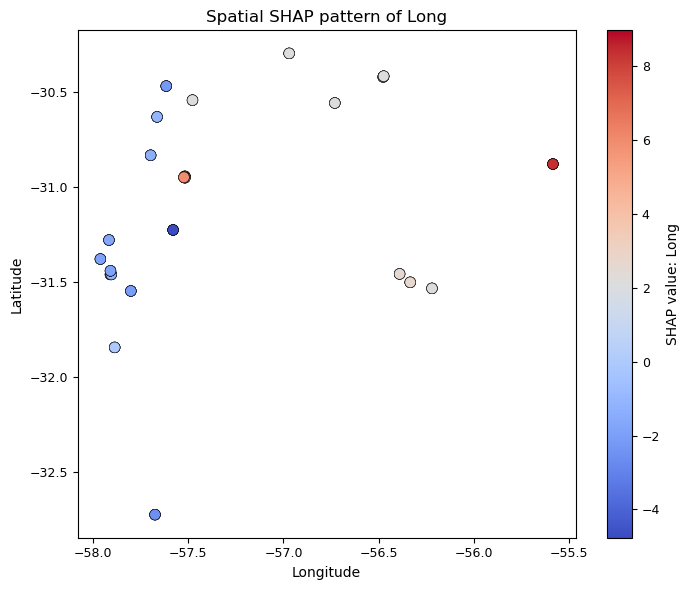

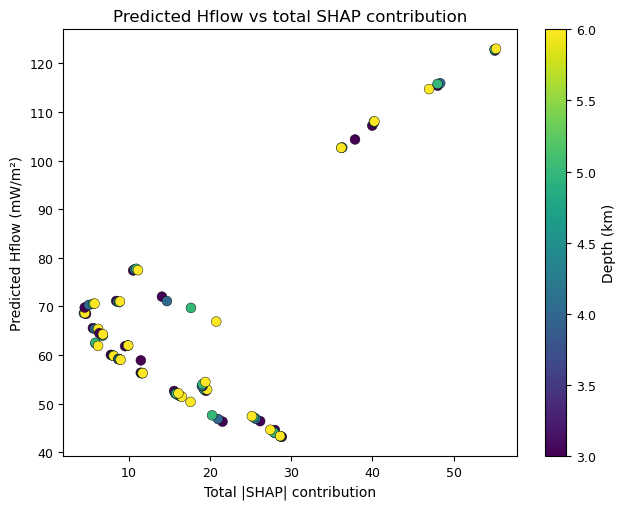


SHAP ANALYSIS COMPLETED
Outputs saved in: shap_hybrid_outputs


In [17]:
# SHAP analysis - Final Hybrid Model

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Install SHAP
try:
    import shap
except ImportError:
    !pip install shap -q
    import shap


# Configuration

output_dir = "shap_hybrid_outputs"
os.makedirs(output_dir, exist_ok=True)
output_dpi = 600

plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})


# Features Dataframe

X_hybrid_df = df_ml[feature_cols_hybrid].copy()
y_hybrid = df_ml['Hflow'].values

print("====================================")
print("SHAP INPUT CHECK")
print("====================================")
print("X shape:", X_hybrid_df.shape)
print("y shape:", y_hybrid.shape)
print("Features:", feature_cols_hybrid)


# Explainer

explainer = shap.TreeExplainer(rf_hybrid)
shap_values = explainer.shap_values(X_hybrid_df)


if isinstance(shap_values, list):
    shap_values = shap_values[0]

print("SHAP values shape:", np.array(shap_values).shape)


# Importance SHAP chart
# ---------------------------------------------------------
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'Feature': feature_cols_hybrid,
    'MeanAbsSHAP': mean_abs_shap
}).sort_values('MeanAbsSHAP', ascending=False).reset_index(drop=True)

print("\n====================================")
print("MEAN ABSOLUTE SHAP IMPORTANCE")
print("====================================")
print(shap_importance_df)

shap_importance_df.to_csv(
    os.path.join(output_dir, "shap_importance_hybrid.csv"),
    index=False
)


# Bar plot global

plt.figure(figsize=(7, 5))
shap.summary_plot(shap_values, X_hybrid_df, plot_type="bar", show=False)
plt.title("Global SHAP importance - Hybrid model")
plt.tight_layout()
plt.savefig(
    os.path.join(output_dir, "shap_bar_hybrid.png"),
    dpi=output_dpi,
    bbox_inches='tight'
)
plt.show()


# Summary

plt.figure(figsize=(8, 5.5))
shap.summary_plot(shap_values, X_hybrid_df, show=False)
plt.title("SHAP summary plot - Hybrid model")
plt.tight_layout()
plt.savefig(
    os.path.join(output_dir, "shap_beeswarm_hybrid.png"),
    dpi=output_dpi,
    bbox_inches='tight'
)
plt.show()


# 3. Dependence plots

candidate_features = ['H_physics', 'grad_T', 'Temp_obs', 'Cond', 'Depth_km', 'Lat', 'Long']
dependence_features = [f for f in candidate_features if f in feature_cols_hybrid]

for feat in dependence_features:
    plt.figure(figsize=(6.8, 5.0))
    shap.dependence_plot(feat, shap_values, X_hybrid_df, interaction_index='auto', show=False)
    plt.title(f"SHAP dependence: {feat}")
    plt.tight_layout()
    plt.savefig(
        os.path.join(output_dir, f"shap_dependence_{feat}.png"),
        dpi=output_dpi,
        bbox_inches='tight'
    )
    plt.show()


# Spatial map SHAP Total

shap_total_abs = np.abs(shap_values).sum(axis=1)

plt.figure(figsize=(7.2, 6.0))
sc = plt.scatter(
    df_ml['Long'],
    df_ml['Lat'],
    c=shap_total_abs,
    cmap='inferno',
    s=60,
    edgecolor='black',
    linewidth=0.35
)
plt.colorbar(sc, label='Total |SHAP| contribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Spatial distribution of total SHAP contribution')
plt.tight_layout()
plt.savefig(
    os.path.join(output_dir, "shap_spatial_total_abs_hybrid.png"),
    dpi=output_dpi,
    bbox_inches='tight'
)
plt.show()


# SHAP maps for each variable

for feat in dependence_features:
    feat_idx = feature_cols_hybrid.index(feat)
    vals = shap_values[:, feat_idx]

    plt.figure(figsize=(7.2, 6.0))
    sc = plt.scatter(
        df_ml['Long'],
        df_ml['Lat'],
        c=vals,
        cmap='coolwarm',
        s=60,
        edgecolor='black',
        linewidth=0.35
    )
    plt.colorbar(sc, label=f'SHAP value: {feat}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Spatial SHAP pattern of {feat}')
    plt.tight_layout()
    plt.savefig(
        os.path.join(output_dir, f"shap_spatial_{feat}_hybrid.png"),
        dpi=output_dpi,
        bbox_inches='tight'
    )
    plt.show()


# Prediction VS CONTRIBUCIÓN SHAP TOTAL

y_pred_hybrid_full = rf_hybrid.predict(X_hybrid_df)

plt.figure(figsize=(6.5, 5.2))
sc = plt.scatter(
    shap_total_abs,
    y_pred_hybrid_full,
    c=df_ml['Depth_km'],
    cmap='viridis',
    s=50,
    edgecolor='black',
    linewidth=0.3
)
plt.xlabel('Total |SHAP| contribution')
plt.ylabel('Predicted Hflow (mW/m²)')
plt.title('Predicted Hflow vs total SHAP contribution')
cb = plt.colorbar(sc)
cb.set_label('Depth (km)')
plt.tight_layout()
plt.savefig(
    os.path.join(output_dir, "shap_total_vs_pred_hybrid.png"),
    dpi=output_dpi,
    bbox_inches='tight'
)
plt.show()

print("\n====================================")
print("SHAP ANALYSIS COMPLETED")
print("Outputs saved in:", output_dir)
print("====================================")